In [467]:
import torch
import time
import torch.nn as nn

from neuromancer.loggers import BasicLogger
import neuromancer.psl as psl
from neuromancer.system import Node, System
from neuromancer.constraint import variable
from neuromancer.loss import PenaltyLoss
from neuromancer.problem import Problem
from neuromancer.dynamics import ode, integrators

from SparseDPC.src.sindy.fx_library import fx_library , fx_policy_library
from SparseDPC.src.data.getdata import get_data, get_policy_data
from SparseDPC.src.trainer.trainer import SparseTrainer
from SparseDPC.src.utils.integrator import OneElementEulerIntegrator, FullStateRK4Integrator

torch.manual_seed(86)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# device = torch.device('cpu')


ImportError: cannot import name 'FullStateRK4Integrator' from 'SparseDPC.src.utils.integrator' (C:\Users\Alireza\PycharmProjects\SparseDPC\SparseDPC\src\utils\integrator.py)

In [2]:
# ground truth system model
gt_model = psl.nonautonomous.VanDerPolControl()
# sampling rate
ts = gt_model.params[1]['ts']
# problem dimensions
nx = gt_model.nx    # number of states
nu = gt_model.nu    # number of control inputs
nref = nx           # number of references
# constraints bounds
umin = -5.
umax = 5.
xmin = -5.
xmax = 5.



In [3]:
fx_models = [fx_library(i, nx=nx, nu=nu, seed=5, device=device,
                           max_degree=4, add_sqrt=False, add_u_prod=True) for i in range(nx)]
for fx in fx_models:
    print(fx)

dx0/dt = 0.266*x0 + -0.113*x1 + 0.230*x0^2 + -0.314*x0*x1 + 0.420*x1^2 + -0.050*x0^3 + -0.485*x0^2*x1 + 0.104*x0*x1^2 + -0.171*x1^3 + 0.105*x0^4 + -0.199*x0^3*x1 + -0.383*x0^2*x1^2 + 0.012*x0*x1^3 + 0.454*x1^4 + 0.440*u_0 + -0.268*x0*u_0 + -0.374*x1*u_0 

dx1/dt = 0.266*x1 + -0.113*x0 + 0.230*x0^2 + -0.314*x0*x1 + 0.420*x1^2 + -0.050*x0^3 + -0.485*x0^2*x1 + 0.104*x0*x1^2 + -0.171*x1^3 + 0.105*x0^4 + -0.199*x0^3*x1 + -0.383*x0^2*x1^2 + 0.012*x0*x1^3 + 0.454*x1^4 + 0.440*u_0 + -0.268*x0*u_0 + -0.374*x1*u_0 



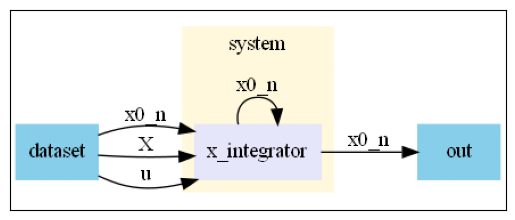

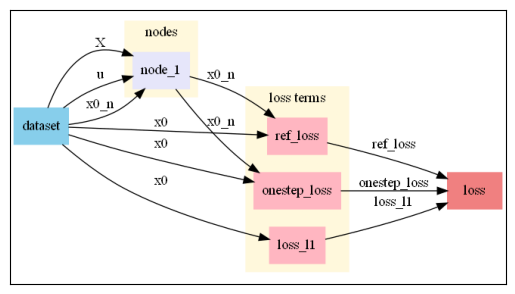

None
epoch: 0	train_loss: 12.02848	dev_loss: 7.60490	eltime:  1.01929
epoch: 100	train_loss: 0.02528	dev_loss: 0.11181	eltime:  20.33289
epoch: 200	train_loss: 0.03897	dev_loss: 0.18120	eltime:  38.32278
epoch: 300	train_loss: 0.00692	dev_loss: 0.01180	eltime:  56.19968
epoch: 400	train_loss: 0.00143	dev_loss: 0.01316	eltime:  74.05642

---------- Model 0 BEFORE pruning ----------
dx0/dt = -0.010*x0 + 0.732*x1 + 0.119*x0^2 + -0.222*x0*x1 + -0.054*x1^2 + -0.005*x0^3 + 0.038*x0^2*x1 + -0.070*x0*x1^2 + 0.038*x1^3 + -0.001*x0^4 + 0.126*x0^3*x1 + -0.085*x0^2*x1^2 + 0.021*x0*x1^3 + 0.007*x1^4 + 0.032*u_0 + -0.111*x0*u_0 + 0.005*x1*u_0 

   Threshold=0.11  Active=5  (prev=17)
   Pruned terms: ['x0', 'x1^2', 'x0^3', 'x0^2*x1', 'x0*x1^2', 'x1^3', 'x0^4', 'x0^2*x1^2', 'x0*x1^3', 'x1^4', 'u_0', 'x1*u_0']

⇒ Active-set changed; only adding small noise to surviving rows.

---------- Model 0 AFTER pruning  ----------
dx0/dt = 0.794*x1 + 0.265*x0^2 + 0.017*x0*x1 + 0.020*x0^3*x1 + -0.240*x0*u_0 

epoc

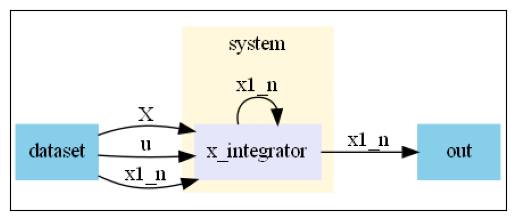

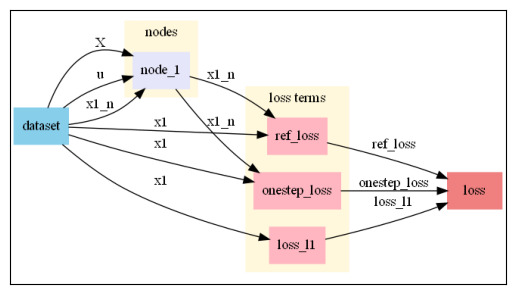

None
epoch: 0	train_loss: 52.40388	dev_loss: 5.87612	eltime:  0.87267
epoch: 100	train_loss: 0.52774	dev_loss: 0.52747	eltime:  18.93637
epoch: 200	train_loss: 0.06309	dev_loss: 0.04030	eltime:  36.91452
epoch: 300	train_loss: 0.01865	dev_loss: 0.01323	eltime:  54.97522
epoch: 400	train_loss: 0.00697	dev_loss: 0.01308	eltime:  72.94218

---------- Model 0 BEFORE pruning ----------
dx1/dt = 0.705*x1 + -0.795*x0 + 0.132*x0^2 + -0.369*x0*x1 + 0.008*x1^2 + -0.001*x0^3 + -0.764*x0^2*x1 + -0.165*x0*x1^2 + 0.017*x1^3 + -0.000*x0^4 + 0.166*x0^3*x1 + 0.001*x0^2*x1^2 + -0.023*x0*x1^3 + 0.014*x1^4 + 0.797*u_0 + -0.133*x0*u_0 + -0.385*x1*u_0 

   Threshold=0.11  Active=10  (prev=17)
   Pruned terms: ['x1^2', 'x0^3', 'x1^3', 'x0^4', 'x0^2*x1^2', 'x0*x1^3', 'x1^4']

⇒ Active-set changed; only adding small noise to surviving rows.

---------- Model 0 AFTER pruning  ----------
dx1/dt = 0.687*x1 + -0.954*x0 + 0.106*x0^2 + -0.393*x0*x1 + -0.618*x0^2*x1 + -0.074*x0*x1^2 + 0.195*x0^3*x1 + 0.713*u_0 + -0.1

In [4]:
for i in range(nx):

    nsim = 2000   # number of simulation steps in the dataset
    nsteps = 2  # number of prediction horizon steps in the loss function
    bs = 100     # minibatching batch size
    train_loader, dev_loader, test_data = get_data(gt_model, nsim, nsteps, ts, bs)

    integrator_x = OneElementEulerIntegrator(fx_models[i], h=ts)
    integrator_node_x = Node(integrator_x, ['X', f'x{i}_n', 'u'], [f'x{i}_n'], name="x_integrator")
    dynamics_model_x = System([integrator_node_x])

    dynamics_model_x.show()

    x = variable(f"x{i}")
    x_hat = variable(f'x{i}_n')[:, :-1, :]

    # Loss
    onestep_loss_x = 1.0 * ((x_hat[:, 1, :] == x[:, 1, :])^ 2)
    onestep_loss_x.name = "onestep_loss"

    reference_loss_x = 5. *((x_hat == x) ^ 2)
    reference_loss_x.name = "ref_loss"

    # Sparsity constraint
    l1_x = variable([x], lambda x: torch.norm(list(fx_models[i].parameters())[0], p=1))
    loss_l1_x = 1e-7 * (l1_x == 0)
    loss_l1_x.name = "loss_l1"

    objectives_x = [reference_loss_x, onestep_loss_x, loss_l1_x]
    loss_x = PenaltyLoss(objectives_x, [])
    problem_x = Problem([dynamics_model_x], loss_x)
    problem_x.show()

    lr = 1e-3
    optimizer_x = torch.optim.AdamW(problem_x.parameters(), lr=lr)

    logger = BasicLogger(args=None, savedir='test', verbosity=100,
                    stdout=['dev_loss', 'train_loss'])
    epochs=1000

    trainer_x = SparseTrainer(
        problem      = problem_x,
        fx_models  = [fx_models[i]],      # list of SINDy models
        lr           = 1e-3,
        train_data=None,
        test_data=None,
        optimizers=[optimizer_x],
        epochs=epochs,
        train_metric='train_loss',
        eval_metric='dev_loss',
        logger=logger,
        device=device,
        threshold=0.11,
        prune_every=500,
        warmup=300,
        patience=50,
        threshold_mult=1.05,
        )
    for _ in range(4):

        train_loader, dev_loader, test_data = get_data(gt_model, nsim, nsteps, ts, bs)
        trainer_x.train_data, trainer_x.dev_data = train_loader, dev_loader
        trainer_x.problem = problem_x  # Keep the problem consistent

        # Train control policy
        best_model = trainer_x.train()


        trainer_x.model.load_state_dict(best_model)

        # Update step size
        nsteps *= 2
        # trainer.model.loss.objectives[2].weight *= 1.1
        dynamics_model_x.nsteps = nsteps



In [333]:
integrator_x = FullStateRK4Integrator(fx_models, ts)          # custom step
x_integrator_node= Node(integrator_x,['xn', 'u'], ['xn'], name=f"x_integrator")


sindy_system = System(
    [x_integrator_node],
    nsteps=nsteps
)

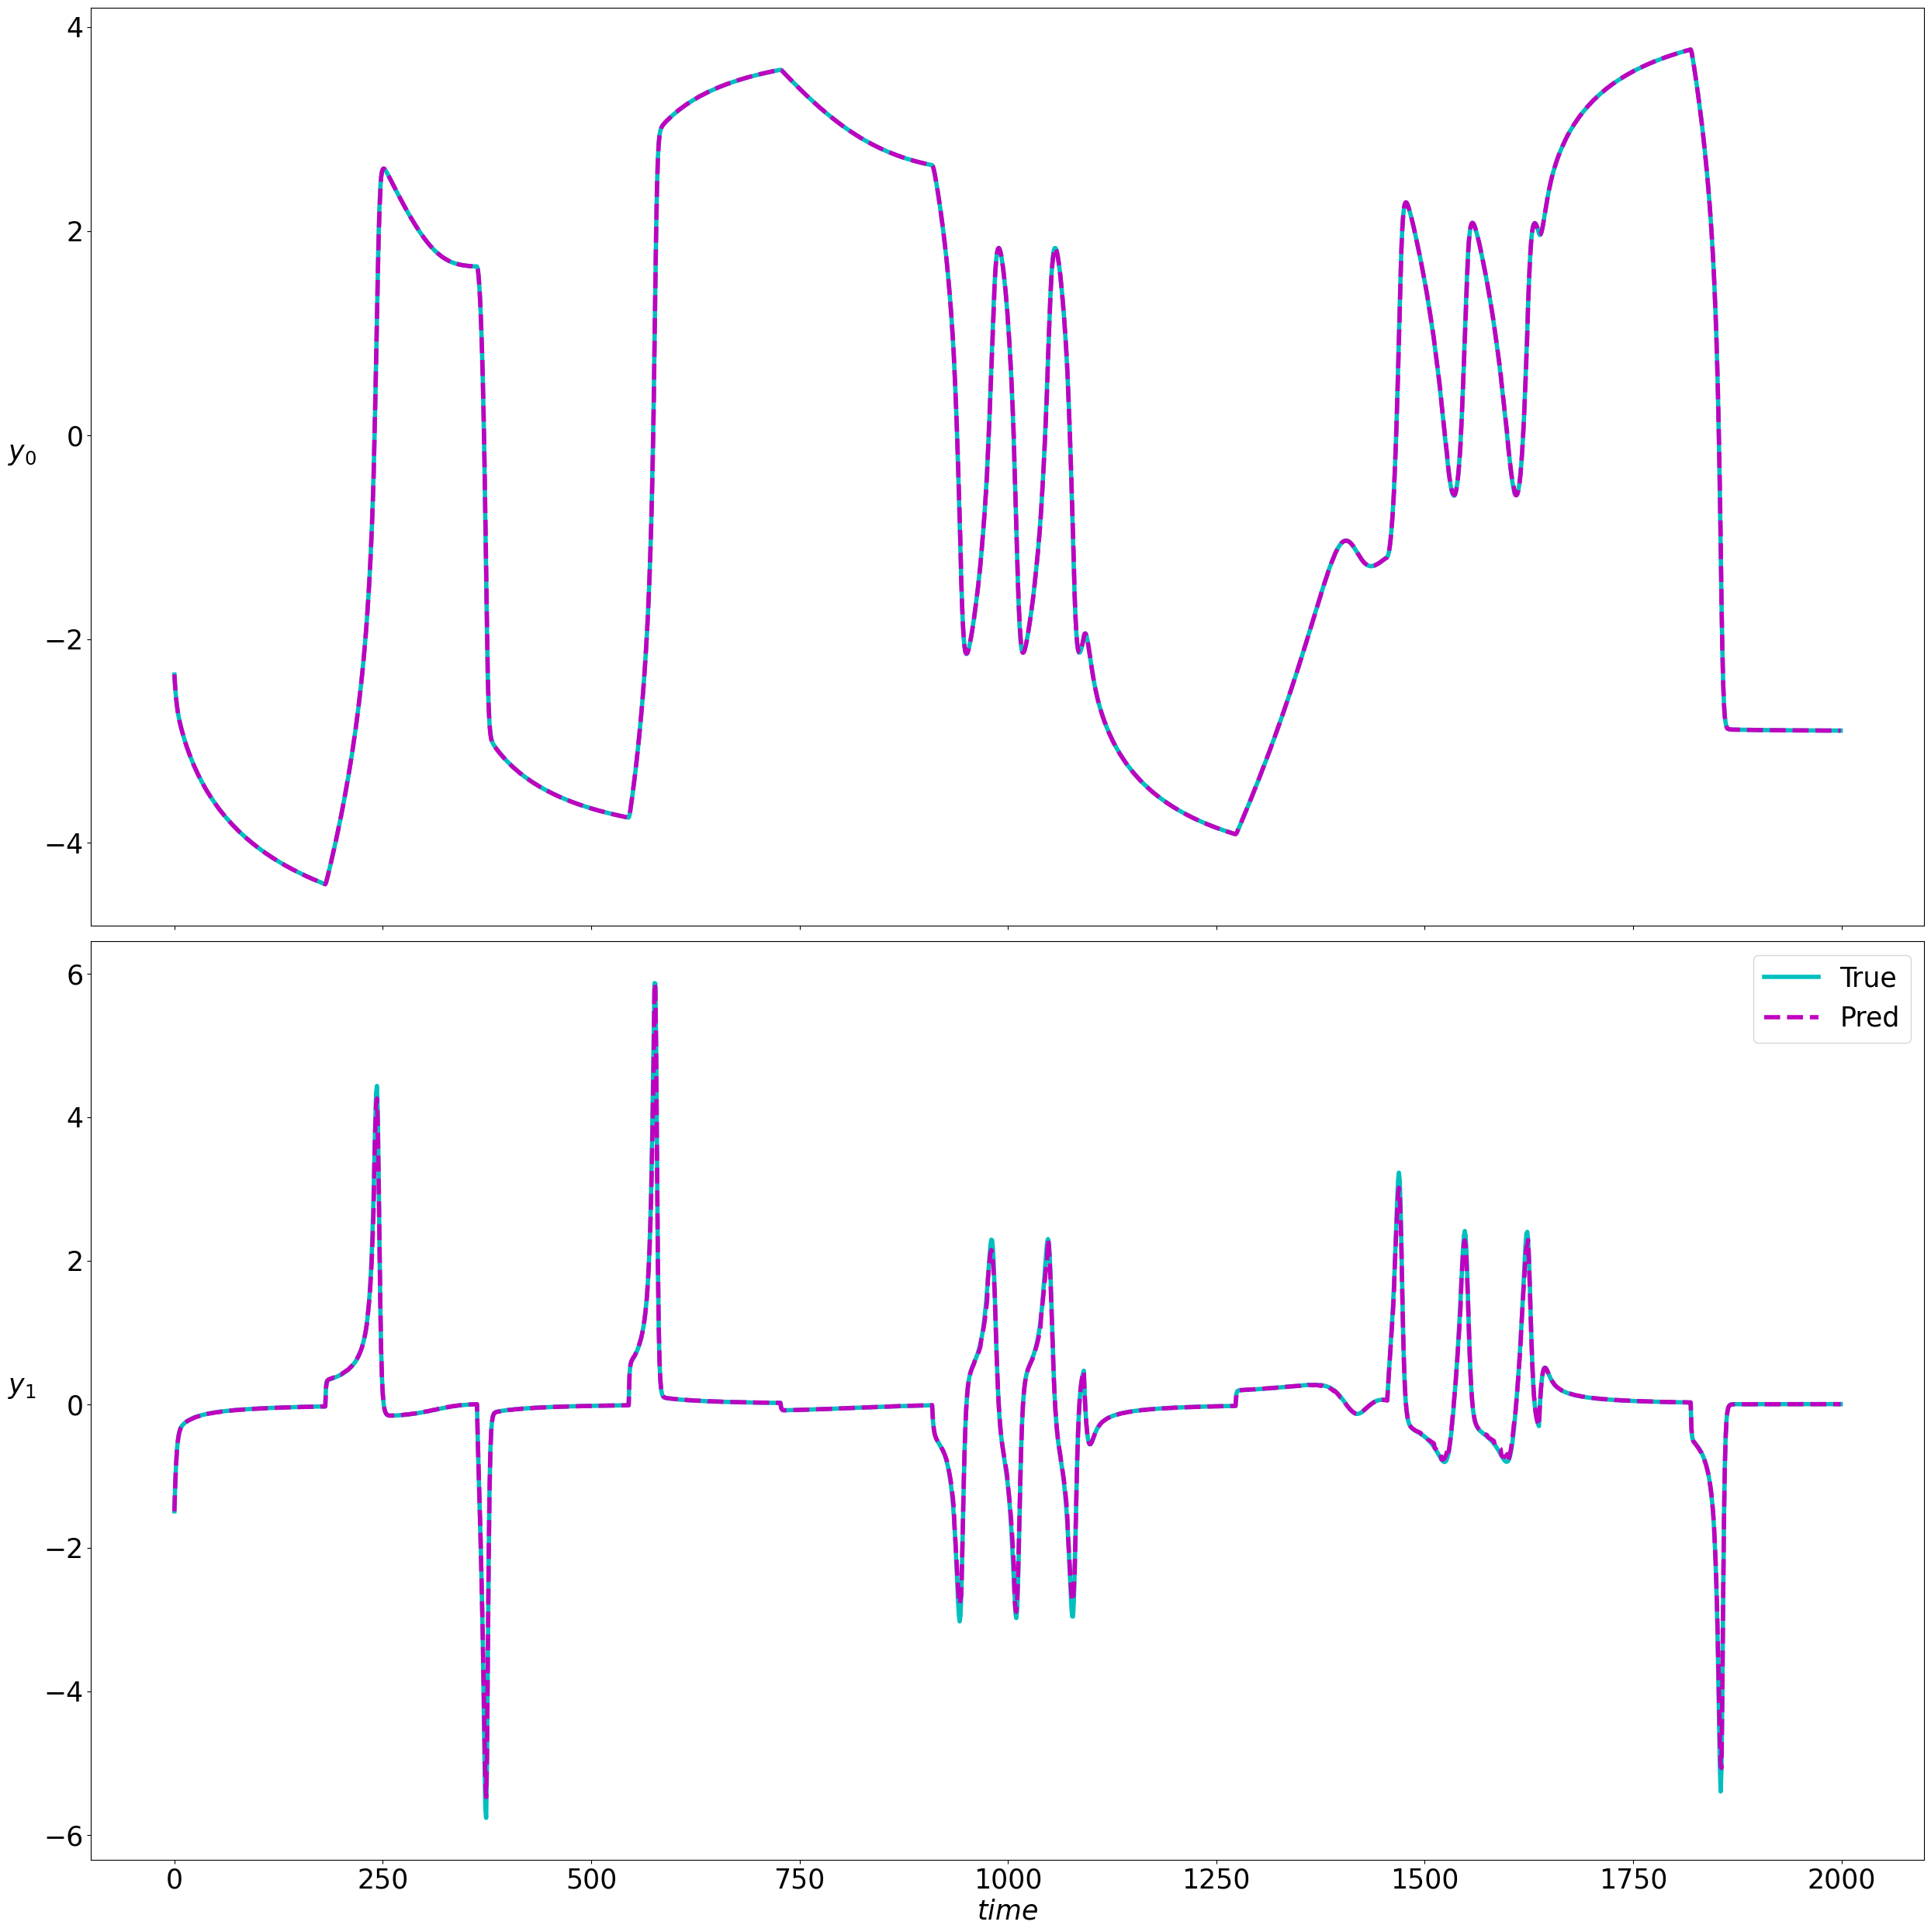

In [334]:
import matplotlib.pyplot as plt

sindy_system.nsteps = test_data['X'].shape[1]
test_output = sindy_system(test_data)

pred_traj = test_output['xn'][:, :-1, :]
true_traj = test_data['X']
pred_traj = pred_traj.detach().numpy().reshape(-1, nx)
true_traj = true_traj.detach().numpy().reshape(-1, nx)
pred_traj, true_traj = pred_traj.transpose(1, 0), true_traj.transpose(1, 0)

figsize = 25
fig, ax = plt.subplots(nx, figsize=(figsize, figsize))
labels = [f'$y_{k}$' for k in range(len(true_traj))]
for row, (t1, t2, label) in enumerate(zip(true_traj, pred_traj, labels)):
    if nx > 1:
        axe = ax[row]
    else:
        axe = ax
    axe.set_ylabel(label, rotation=0, labelpad=20, fontsize=figsize)
    axe.plot(t1, 'c', linewidth=4.0, label='True')
    axe.plot(t2, 'm--', linewidth=4.0, label='Pred')
    axe.tick_params(labelbottom=False, labelsize=figsize)
axe.tick_params(labelbottom=True, labelsize=figsize)
axe.legend(fontsize=figsize)
axe.set_xlabel('$time$', fontsize=figsize)
plt.tight_layout()

In [445]:
# from neuromancer.dataset import DictDataset
# from torch.utils.data import DataLoader
# import torch
# from SparseDPC.src.sindy.library import FunctionLibrary
# from SparseDPC.src.sindy.sindy import SINDy
#
# def get_policy_data_local(nsteps, n_samples):
#     #  sampled references for training the policy
#     list_refs = [torch.zeros(n_samples, nsteps+1, nx)]
#     ref = torch.cat(list_refs)
#     batched_ref = ref.reshape([n_samples, nsteps+1, nref])
#     train_xn = torch.rand(n_samples, 1, nx)
#     train_x1_n = train_xn[:,:,0:1]
#     train_x2_n = train_xn[:,:,1:2]
#     # Training dataset
#     train_data = DictDataset({'xn': train_xn.to(device),   # sampled initial conditions of states
#                               'x1_n': train_x1_n.to(device),
#                               'x2_n': train_x2_n.to(device),
#                               'r': batched_ref.to(device)}, name='train')
#
#     # sampled references for development set
#     list_refs = [torch.zeros(n_samples, nsteps+1, nx)]
#     ref = torch.cat(list_refs)
#     batched_ref = ref.reshape([n_samples, nsteps+1, nref])
#     dev_xn = torch.rand(n_samples, 1, nx)
#     dev_x1_n = dev_xn[:,:,0:1]
#     dev_x2_n = dev_xn[:,:,1:2]
#     # Development dataset
#     dev_data = DictDataset({'xn': dev_xn.to(device),   # sampled initial conditions of states
#                               'x1_n': dev_x1_n.to(device),
#                               'x2_n': dev_x2_n.to(device),
#                               'r': batched_ref.to(device)}, name='dev')
#
#     # torch dataloaders
#     batch_size = 200
#     train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size,
#                                                collate_fn=train_data.collate_fn,
#                                                shuffle=False)
#     dev_loader = torch.utils.data.DataLoader(dev_data, batch_size=batch_size,
#                                              collate_fn=dev_data.collate_fn,
#                                              shuffle=False)
#     return train_loader, dev_loader
#
# import itertools
#
# def fx_policy_library_local(policy_name, seed, device):
#     n_features = 2  # assumes nx = 2
#     n_controls = 0
#
#     theta_funs = []
#     theta_names = []
#
#     # --- Linear terms ---
#     for i in range(n_features):
#         theta_funs.append(lambda X, i=i: X[:, i])
#         theta_names.append(f"x_{i}")
#
#     # --- Trigonometric terms ---
#     for i in range(n_features):
#         theta_funs.append(lambda X, i=i: torch.sin(X[:, i]))
#         theta_names.append(f"sin(x_{i})")
#
#         theta_funs.append(lambda X, i=i: torch.cos(X[:, i]))
#         theta_names.append(f"cos(x_{i})")
#
#         theta_funs.append(lambda X, i=i: torch.sin(2 * X[:, i]))
#         theta_names.append(f"sin(2x_{i})")
#
#         theta_funs.append(lambda X, i=i: torch.cos(2 * X[:, i]))
#         theta_names.append(f"cos(2x_{i})")
#
#         theta_funs.append(lambda X, i=i: X[:, i] * torch.sin(X[:, i]))
#         theta_names.append(f"x_{i}sin(x_{i})")
#
#         theta_funs.append(lambda X, i=i: X[:, i] * torch.cos(X[:, i]))
#         theta_names.append(f"x_{i}cos(x_{i})")
#
#     # --- Quadratic terms ---
#     for i in range(n_features):
#         theta_funs.append(lambda X, i=i: X[:, i] ** 2)
#         theta_names.append(f"x_{i}^2")
#
#     for i, j in itertools.combinations(range(n_features), 2):
#         theta_funs.append(lambda X, i=i, j=j: X[:, i] * X[:, j])
#         theta_names.append(f"x_{i} * x_{j}")
#
#     # --- Cubic terms ---
#     for i in range(n_features):
#         theta_funs.append(lambda X, i=i: X[:, i] ** 3)
#         theta_names.append(f"x_{i}^3")
#
#     # Cross cubic: x_i^2 * x_j and x_i * x_j^2
#     for i, j in itertools.permutations(range(n_features), 2):
#         theta_funs.append(lambda X, i=i, j=j: (X[:, i] ** 2) * X[:, j])
#         theta_names.append(f"x_{i}^2 * x_{j}")
#
#     # Create function library
#     theta_library = FunctionLibrary(theta_funs, 1, n_controls, theta_names)
#
#     return SINDy(library=theta_library, policy_name=policy_name, seed=seed, device=device)

In [480]:
nsteps = 50  # prediction horizon
n_samples = 1000   # number of sampled scenarios
train_loader, dev_loader = get_policy_data(nsteps=nsteps,
                                           n_samples=n_samples,
                                           nx=nx,
                                           xmin=xmin,
                                           xmax=xmax,
                                           same_ref_for_all_states=True,
                                           device=device,
                                           batch_size=200,
                                           seed=5
                                           )

In [485]:
policies_seed = 5
fx_policies = [fx_policy_library(nx=nx, nref=0, policy_name= "u", seed=policies_seed, device=device)]
coef_init = 2.0 * torch.rand(fx_policies[0].library.shape[0], 1, device=device)
for fp in fx_policies:
    fp.coef   = torch.nn.Parameter(coef_init, requires_grad=True)

for fp in fx_policies:
    print(fp)

u = 0.350*x_0 + 1.749*x_1 + 0.197*sin(x_0) + 1.459*sin(x_1) + 1.381*cos(x_0) + 0.708*cos(x_1) + 1.881*sin(2*x_0) + 0.902*sin(2*x_1) + 0.334*cos(2*x_0) + 1.379*cos(2*x_1) + 0.324*x_0*sin(x_0) + 0.479*x_1*sin(x_1) + 1.580*x_0*cos(x_0) + 1.455*x_1*cos(x_1) + 0.860*x_0 * x_1 



In [486]:
for fp in fx_policies:
    print(fp)

for fx in fx_models:
    print(fx)

u = 0.350*x_0 + 1.749*x_1 + 0.197*sin(x_0) + 1.459*sin(x_1) + 1.381*cos(x_0) + 0.708*cos(x_1) + 1.881*sin(2*x_0) + 0.902*sin(2*x_1) + 0.334*cos(2*x_0) + 1.379*cos(2*x_1) + 0.324*x_0*sin(x_0) + 0.479*x_1*sin(x_1) + 1.580*x_0*cos(x_0) + 1.455*x_1*cos(x_1) + 0.860*x_0 * x_1 

dx0/dt = 1.001*x1 

dx1/dt = 0.829*x1 + -0.983*x0 + -0.958*x0^2*x1 + 0.985*u_0 



In [487]:
import torch.nn as nn


class FullStateRK4Integrator(nn.Module):
    """
    One-step 4th-order Runge–Kutta that evolves the *entire* state vector x
    when you have **one scalar-output model per state component** in
    `fx_list`.

    Each fx_i must implement  f_i(x, u) → ẋ_i (shape: B×1).

    Parameters
    ----------
    fx_list : list[nn.Module]   – length = nx, one SINDy model per state
    h       : float or 0-D tensor  – time step
    """
    def __init__(self, fx_list, h):
        super().__init__()
        self.fx_list = nn.ModuleList(fx_list)
        self.h       = torch.as_tensor(h)          # allows scalar or tensor

    # ---- helper to evaluate all f_i ----------------------------------------
    def _f(self, x, u):
        """Return full derivative vector ẋ matching x’s shape."""
        dx = torch.empty_like(x)
        for i, fx in enumerate(self.fx_list):
            dx[:, i:i+1] = fx(x, u)                # (B,1)
        return dx

    # ---- RK4 step -----------------------------------------------------------
    @torch.no_grad()
    def forward(self, x, u):
        """
        x : (B, nx)   – current state
        u : (B, nu)   – control input
        returns next state  x_{k+1}
        """
        h = self.h
        k1 = self._f(x, u)  # k1 = f(x_i, t_i)
        k2 = self._f(x + h * k1 / 2.0, u)  # k2 = f(x_i + 0.5*h*k1, t_i + 0.5*h)
        k3 = self._f(x + h * k2 / 2.0, u)  # k3 = f(x_i + 0.5*h*k2, t_i + 0.5*h)
        k4 = self._f(x + h * k3, u)  # k4 = f(y_i + h*k3, t_i + h)
        return x + h * (k1 / 6.0 + k2 / 3.0 + k3 / 3.0 + k4 / 6.0)


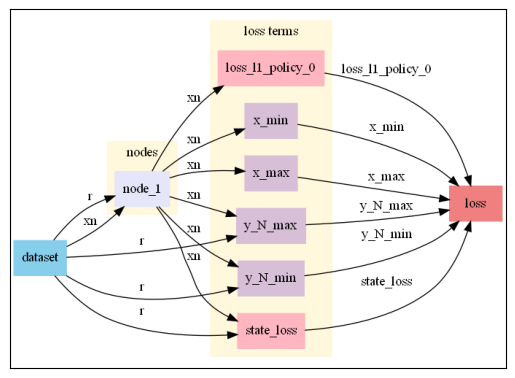

None
*** training with 50 steps ***
epoch: 0	train_loss: 29.41079	dev_loss: 28.84617	eltime:  2.60201
epoch: 1	train_loss: 29.41079	dev_loss: 28.84617	eltime:  5.05944
epoch: 2	train_loss: 29.41079	dev_loss: 28.84617	eltime:  7.32338
epoch: 3	train_loss: 29.41079	dev_loss: 28.84617	eltime:  9.83068
epoch: 4	train_loss: 29.41079	dev_loss: 28.84617	eltime:  12.43472
epoch: 5	train_loss: 29.41079	dev_loss: 28.84617	eltime:  14.88716
epoch: 6	train_loss: 29.41079	dev_loss: 28.84617	eltime:  17.34658
epoch: 7	train_loss: 29.41079	dev_loss: 28.84617	eltime:  19.68832
epoch: 8	train_loss: 29.41079	dev_loss: 28.84617	eltime:  21.95725
Training interrupted by user.
Policy 0:
u = 0.350*x_0 + 1.749*x_1 + 0.197*sin(x_0) + 1.459*sin(x_1) + 1.381*cos(x_0) + 0.708*cos(x_1) + 1.881*sin(2*x_0) + 0.902*sin(2*x_1) + 0.334*cos(2*x_0) + 1.379*cos(2*x_1) + 0.324*x_0*sin(x_0) + 0.479*x_1*sin(x_1) + 1.580*x_0*cos(x_0) + 1.455*x_1*cos(x_1) + 0.860*x_0 * x_1 




In [488]:
# ------------------------------------------------------------------ #
# 0.  Combined policy (any #policies)
# ------------------------------------------------------------------ #
policy_node = Node(
    lambda xn, r: torch.cat(
        [torch.clamp(fp(xn, r), umin, umax)  # capture fp by value
         for fp in fx_policies],
        dim=-1),
    ['xn', 'r'], ['u'],
    name="policy_combined"
)

# ------------------------------------------------------------------ #
# build integrator node and system
# ------------------------------------------------------------------ #

integrator_x = FullStateRK4Integrator(fx_models, ts)
x_integrator_node= Node(integrator_x,['xn', 'u'], ['xn_pred'], name=f"x_integrator")
xbound = Node(lambda x: torch.clamp(x, xmin, xmax), ['xn_pred'], ['xn'], name="x_bound")
sindy_system = System(
    [policy_node, x_integrator_node, xbound],
    nsteps=nsteps
)



# ODE model with no-plant model mismatch
# van_der_pol = ode.VanDerPolControl()                   # ODE system equations implemented in PyTorch
# van_der_pol.mu = nn.Parameter(torch.tensor(van_der_pol.mu, device=device), requires_grad=False)

# integrate continuous time ODE
# gt_integrator = integrators.RK4(van_der_pol, h=torch.tensor(ts))   # using 4th order runge kutta integrator
# symbolic system model
# gt_integrator_node = Node(gt_integrator, ['xn', 'u'], ['xn_pred'], name='model')

#
# xbound = Node(lambda x: torch.clamp(x, xmin, xmax), ['xn_pred'], ['xn'], name="x_bound")
# sindy_system = System(
#     [policy_node, gt_integrator_node, xbound],
#     nsteps=nsteps
# )


# ------------------------------------------------------------------ #
# 4.  Objectives
# ------------------------------------------------------------------ #
x   = variable('xn')
ref = variable('r')

regulation_loss      = 5.0 * ((x == ref) ^ 2); regulation_loss.name = "state_loss"

#   L1 sparsity for each policy
loss_l1_policies = []
for idx, fp in enumerate(fx_policies):
    l1_raw  = variable([x],
                       lambda y, fp=fp: torch.norm(list(fp.parameters())[0], p=1),
                       display_name=f"l1_policy{idx}")
    l1_pen  = 1e-30 * (l1_raw == 0)
    l1_pen.name = f"loss_l1_policy_{idx}"
    loss_l1_policies.append(l1_pen)

# ------------------------------------------------------------------ #
# 5.  Constraints
# ------------------------------------------------------------------ #
state_lower  = 2.0 * (x > xmin);           state_lower.name  = "x_min"
state_upper  = 2.0 * (x < xmax);           state_upper.name  = "x_max"
term_lower   = 2.0 * (x[:, [-1], :] > ref - 0.01); term_lower.name = "y_N_min"
term_upper   = 2.0 * (x[:, [-1], :] < ref + 0.01); term_upper.name = "y_N_max"

# ------------------------------------------------------------------ #
# 6.  Problem definition
# ------------------------------------------------------------------ #
objectives  = [regulation_loss, *loss_l1_policies]
constraints = [state_lower, state_upper, term_lower, term_upper]

loss     = PenaltyLoss(objectives, constraints)
problem  = Problem([sindy_system], loss)
problem.show()

# ------------------------------------------------------------------ #
# 7.  Optimiser & trainer
# ------------------------------------------------------------------ #
lr         = 0.008
optimizers = [torch.optim.Adam(fp.parameters(), lr=lr) for fp in fx_policies]

trainer_policy = SparseTrainer(
    problem     = problem,
    fx_models   = fx_policies,
    lr          = lr,
    train_data  = train_loader,
    dev_data    = dev_loader,
    optimizers  = optimizers,
    epochs      = 1200,
    train_metric='train_loss',
    eval_metric ='dev_loss',
    logger      = BasicLogger(args=None, savedir='test', verbosity=1,
                              stdout=['dev_loss', 'train_loss']),
    device      = device,
    threshold   = 0.20,
    prune_every = 100,
    threshold_mult=1.11
)

print(f"*** training with {nsteps} steps ***")
best_state = trainer_policy.train()
trainer_policy.model.load_state_dict(best_state)

for i, fp in enumerate(fx_policies):
    print(f"Policy {i}:\n{fp}\n")


In [425]:
print(fx_policies[0])

u = 0.323*x_0 + 0.512*x_1 + 0.634*sin(x_0) + -0.005*cos(x_0) + -0.027*sin(2x_0) + 0.742*cos(2x_0) + 0.568*x_0sin(x_0) + 0.779*x_0cos(x_0) + 0.036*sin(x_1) + 0.709*cos(x_1) + 0.653*sin(2x_1) + 0.985*cos(2x_1) + 0.300*x_1sin(x_1) + 0.432*x_1cos(x_1) + 0.422*x_0^2 + 0.225*x_1^2 + 0.464*x_0 * x_1 + 0.702*x_0^3 + 0.056*x_1^3 + 0.418*x_0^2 * x_1 + 0.061*x_1^2 * x_0 



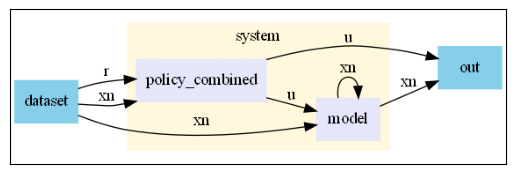

In [456]:
# white-box
policy_node = Node(
    lambda xn, r: torch.cat(
        [torch.clamp(fp(xn, r), umin, umax).to(torch.device('cpu'))  # capture fp by value
         for fp in fx_policies],
        dim=-1),
    ['xn', 'r'], ['u'],
    name="policy_combined"
)


# ODE model with no-plant model mismatch
van_der_pol = ode.VanDerPolControl()                   # ODE system equations implemented in PyTorch
# integrate continuous time ODE
gt_integrator = integrators.RK4(van_der_pol, h=torch.tensor(ts))   # using 4th order runge kutta integrator
# symbolic system model
gt_integrator_node = Node(gt_integrator, ['xn', 'u'], ['xn'], name='model')

import copy
gt_sindy_policy = copy.deepcopy(System([policy_node,
                       gt_integrator_node]))
gt_sindy_policy.show()

(<Figure size 2000x1600 with 2 Axes>,
 array([[<Axes: xlabel='Time', ylabel='y'>],
        [<Axes: xlabel='Time', ylabel='u'>]], dtype=object))

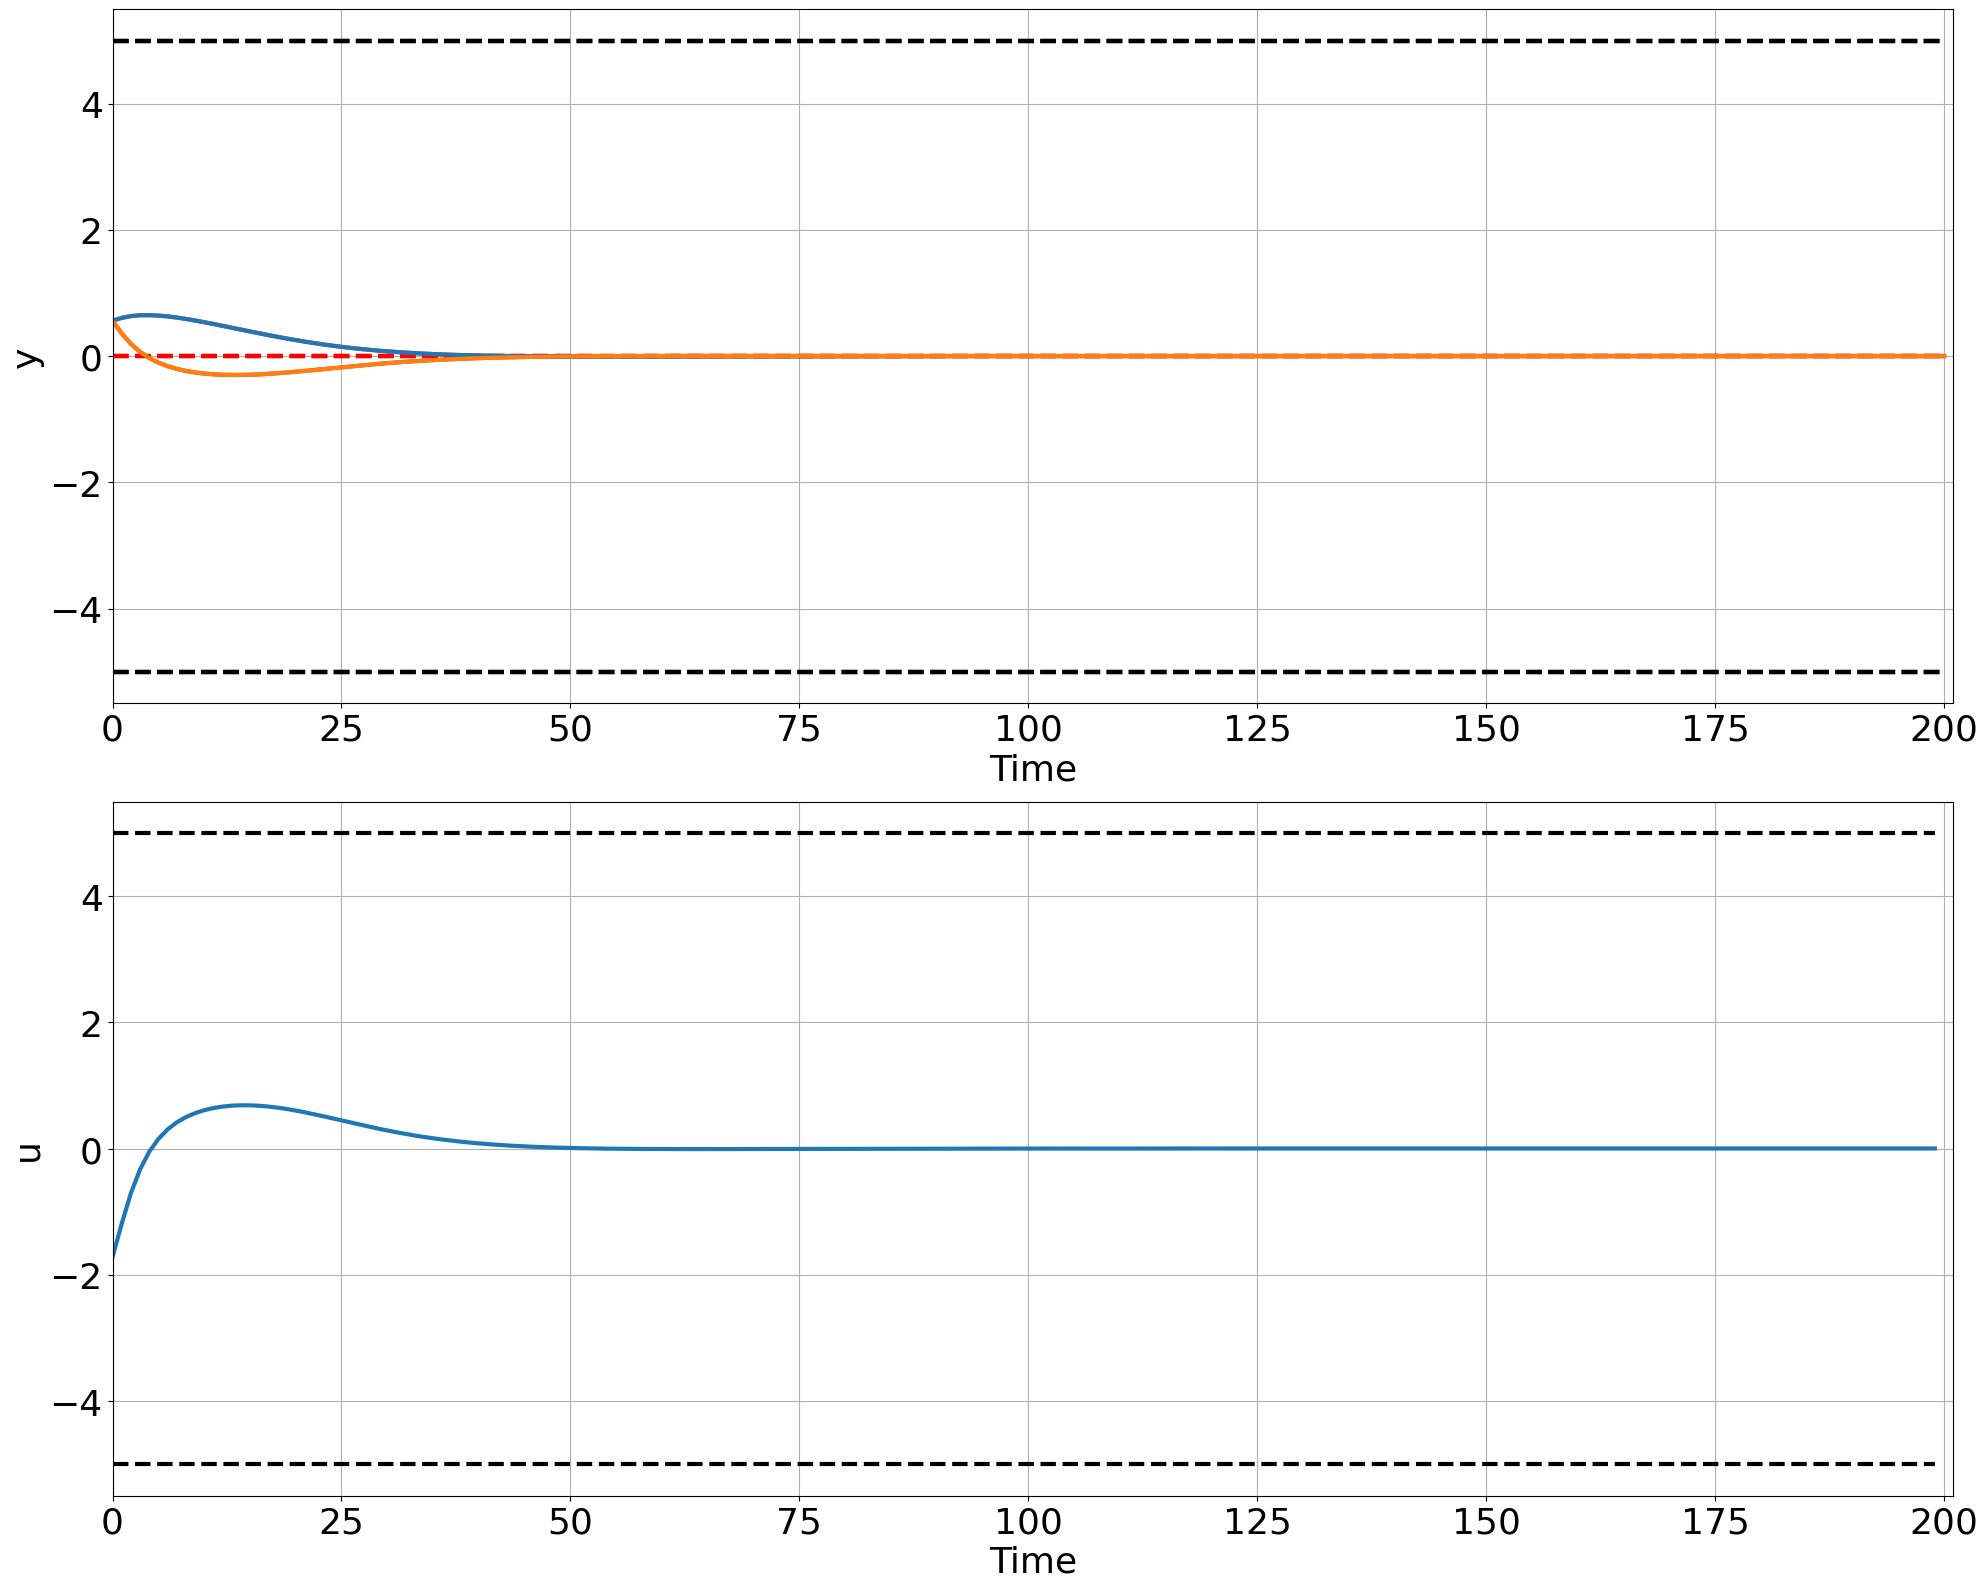

In [457]:
import numpy as np
from neuromancer.plot import pltCL, pltPhase

nsteps = 200
torch.manual_seed(4)
seed = 10
rng = np.random.default_rng(seed)
# generate reference
torch_ref = torch.zeros(1,nsteps+1,2)

data = {'xn': torch.rand(1, 1, nx),
        'r' : torch_ref}

gt_sindy_policy.nsteps = nsteps
# perform closed-loop simulation
trajectories_before_adaptation = gt_sindy_policy(data)

# constraints bounds
Umin = umin * np.ones([nsteps, nu])
Umax = umax * np.ones([nsteps, nu])
Xmin = xmin * np.ones([nsteps+1, nx])
Xmax = xmax * np.ones([nsteps+1, nx])
# plot closed loop trajectories
pltCL(Y=trajectories_before_adaptation['xn'].detach().cpu().reshape(nsteps + 1, nx),
      R=trajectories_before_adaptation['r'].detach().cpu().reshape(nsteps + 1, nref),
      U=trajectories_before_adaptation['u'].detach().cpu().reshape(nsteps, nu),
      Umin=Umin, Umax=Umax, Ymin=Xmin, Ymax=Xmax)

In [49]:
van_der_pol

VanDerPolControl()